1 Arad
2 Bucharest
3 Craiova
4 Dobreta
5 Eforie
6 Fagaras
7 Giurgiu
8 Hirsova
9 Iasi
10 Lugoj
11 Mehadia
12 Neamt
13 Oradea
14 Pitesti
15 Rimnicu_Vilcea
16 Sibiu
17 Timisoara
18 Urziceni
19 Vaslui
20 Zerind


Please enter your desired start city's number (0 for exit):  3


Craiova 

{'Arad': 366, 'Bucharest': 0, 'Craiova': 160, 'Dobreta': 242, 'Eforie': 161, 'Fagaras': 178, 'Giurgiu': 77, 'Hirsova': 151, 'Iasi': 226, 'Lugoj': 244, 'Mehadia': 241, 'Neamt': 234, 'Oradea': 380, 'Pitesti': 98, 'Rimnicu_Vilcea': 193, 'Sibiu': 253, 'Timisoara': 329, 'Urziceni': 80, 'Vaslui': 199, 'Zerind': 374} 

{'Arad': [['Sibiu', '140'], ['Timisoara', '118'], ['Zerind', '75']], 'Sibiu': [['Arad', '140'], ['Fagaras', '99'], ['Oradea', '151'], ['Rimnicu_Vilcea', '80']], 'Timisoara': [['Arad', '118'], ['Lugoj', '111']], 'Zerind': [['Arad', '75'], ['Oradea', '71']], 'Bucharest': [['Fagaras', '211'], ['Giurgiu', '90'], ['Pitesti', '101'], ['Urziceni', '85']], 'Fagaras': [['Bucharest', '211'], ['Sibiu', '99']], 'Giurgiu': [['Bucharest', '90']], 'Pitesti': [['Bucharest', '101'], ['Craiova', '138'], ['Rimnicu_Vilcea', '97']], 'Urziceni': [['Bucharest', '85'], ['Hirsova', '98'], ['Vaslui', '142']], 'Craiova': [['Dobreta', '120'], ['Pitesti', '138'], ['Rimnicu_Vilcea', '146']], 'Dobr

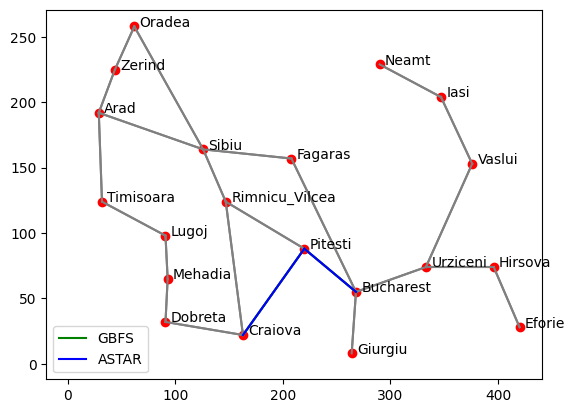

In [ ]:
###### Heuristically Informed Searches ######
"""
Heuristic value along with distance of each city of Romania is provided in
the files (cities.txt, citiesGraph.txt and heuristics.txt)
Read these files uing python file open function and readlines


1) Greedy Best First Search
2) A* Star Search

NOTE:- A) THE DRIVER CODE IS GIVEN FOR YOUR REFERENCE AND AID PURPOSE
       B) DON'T ALTER THE CODE, YOU WILL NOT GET THE DESIRED OUTPUT VISULIZATION IF SO
       C) DON'T USE ANY LIBRARY, THOUGH YOU MAY JUST USE THE QUEUE AND MATPLOT LIBRARIES
       D) DRAWMAP FUNCTION IS JUST A UTILITY FUNCTION, TO SHOW YOUR OUTPUT AS DISCUSSED 
       IN THE CLASS
       E) THIS IS A SOLO TASK, YOU MAY NOT DISCUSS WITH YOU LAB GROUP MEMBERS
"""


import queue
import matplotlib.pyplot as plt

# getting heuristics from file
def getHeuristics():
    heuristics = {}
    f = open("heuristics.txt")
    for i in f.readlines():
        node_heuristic_val = i.split()
        heuristics[node_heuristic_val[0]] = int(node_heuristic_val[1])

    return heuristics


# getting cities location from file
def getCity():
    city = {}
    citiesCode = {}
    f = open("cities.txt")
    j = 1
    for i in f.readlines():
        node_city_val = i.split()
        city[node_city_val[0]] = [int(node_city_val[1]), int(node_city_val[2])]

        citiesCode[j] = node_city_val[0]
        j += 1

    return city, citiesCode


# creating cities graph from file
def createGraph():
    graph = {}
    file = open("citiesGraph.txt")
    for i in file.readlines():
        node_val = i.split()

        if node_val[0] in graph and node_val[1] in graph:
            c = graph.get(node_val[0])
            c.append([node_val[1], node_val[2]])
            graph.update({node_val[0]: c})

            c = graph.get(node_val[1])
            c.append([node_val[0], node_val[2]])
            graph.update({node_val[1]: c})

        elif node_val[0] in graph:
            c = graph.get(node_val[0])
            c.append([node_val[1], node_val[2]])
            graph.update({node_val[0]: c})

            graph[node_val[1]] = [[node_val[0], node_val[2]]]

        elif node_val[1] in graph:
            c = graph.get(node_val[1])
            c.append([node_val[0], node_val[2]])
            graph.update({node_val[1]: c})

            graph[node_val[0]] = [[node_val[1], node_val[2]]]

        else:
            graph[node_val[0]] = [[node_val[1], node_val[2]]]
            graph[node_val[1]] = [[node_val[0], node_val[2]]]

    return graph


# Greedy Best First Search Algorithm
def GBFS(startNode, heuristics, graph, goalNode="Bucharest"):
    ### COMPLETE THE FUNCTION THAT SHOULD ONLY RETURN THE PATH 
    ### OF BEST FIRST SEARCH ALGORITHM
    ### DON'T ALTER THE PARAMETERS OF FUNCTIONS
    ### WRITE ONLY THE LOGIC OF BEST FIRST SEARCH

    print(startNode, '\n')
    print(heuristics, '\n')
    print(graph, '\n')

    queue1 = queue.PriorityQueue()
    path = []
    visited = []
    queue1.put(heuristics[startNode])
    visited.append(startNode)
    while (not queue1.empty()):
        thisNode = 'null'
        thisHeuristic = queue1.get()
        for i,j in heuristics.items():
            if(j == thisHeuristic):
                thisNode = i
        print(thisNode)
        path.append(thisNode)
        if(thisNode == goalNode):
            break
        for i in graph[thisNode]:
            if (i[0] not in visited):
                queue1.put(heuristics[i[0]])
                visited.append(i[0])

    print("VISITED LIST: ", visited, '\n')
    print("FINAL PATH: ", path, '\n')
    return path


# Astar Algorithm
def Astar(startNode, heuristics, graph, goalNode="Bucharest"):
    ### COMPLETE THE FUNCTION THAT SHOULD ONLY RETURN THE PATH 
    ### OF A-STAR SEARCH ALGORITHM
    ### DON'T ALTER THE PARAMETERS OF FUNCTIONS
    ### WRITE ONLY THE LOGIC OF A-STAR SEARCH
    print(startNode, '\n')
    print(heuristics, '\n')
    print(graph, '\n')

    queue1 = queue.PriorityQueue()
    path = []
    visited = []
    queue1.put([heuristics[startNode]+0, startNode])
    visited.append(startNode)
    while (not queue1.empty()):
        thisItem = queue1.get()
        thisNode = thisItem[1]
        path.append(thisNode)
        if (thisNode == goalNode):
            break
        for i in graph[thisNode]:
            if (i[0] not in visited):
                queue1.put([heuristics[i[0]] + int(i[1]), i[0]])
                visited.append(i[0])


    print("VISITED LIST: ", visited, '\n')
    print("FINAL PATH: ", path)
    return path


# drawing map of answer
def drawMap(city, gbfs, astar, graph):
    for i, j in city.items():
        plt.plot(j[0], j[1], "ro")
        plt.annotate(i, (j[0] + 5, j[1]))

        for k in graph[i]:
            n = city[k[0]]
            plt.plot([j[0], n[0]], [j[1], n[1]], "gray")

    for i in range(len(gbfs)):
        try:
            first = city[gbfs[i]]
            secend = city[gbfs[i + 1]]

            plt.plot([first[0], secend[0]], [first[1], secend[1]], "green")
        except:
            continue

    for i in range(len(astar)):
        try:
            first = city[astar[i]]
            secend = city[astar[i + 1]]

            plt.plot([first[0], secend[0]], [first[1], secend[1]], "blue")
        except:
            continue

    plt.errorbar(1, 1, label="GBFS", color="green")
    plt.errorbar(1, 1, label="ASTAR", color="blue")
    plt.legend(loc="lower left")

    plt.show()


# running the program
def main():
    heuristic = getHeuristics()
    graph = createGraph()
    city, citiesCode = getCity()

    for i, j in citiesCode.items():
        print(i, j)

    while True:
        inputCode = int(input("Please enter your desired start city's number (0 for exit): "))

        if inputCode == 0:
            break

        cityName = citiesCode[inputCode]


        gbfs = GBFS(cityName, heuristic, graph)
        astar = Astar(cityName, heuristic, graph)
        print("GBFS => ", gbfs)
        print("ASTAR => ", astar)

        drawMap(city, gbfs, astar, graph)


if __name__ == '__main__':
    main()
